<a href="https://colab.research.google.com/github/Vedant2100/w26/blob/main/ToT_Agent_MiniGrid_V3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tree-of-Thought (ToT) Agent for MiniGrid
**EE 238 Final Project — Bhargav Srikanta Prasad Hoskote**


In [ ]:
#  !pip install vllm openai gymnasium minigrid imageio

## 1. Start vLLM Server

In [ ]:
import subprocess
import time

model_name = "Qwen/Qwen2.5-7B-Instruct"

print(f"Loading vLLM server with model: {model_name}...")
print("This takes ~3-4 minutes on Colab GPU.")

command = (
    f"nohup python -m vllm.entrypoints.openai.api_server "
    f"--model {model_name} --dtype auto --api-key empty --port 8000 "
    f"> vllm_server.log 2>&1 &"
)
subprocess.run(command, shell=True)

Loading vLLM server with model: Qwen/Qwen2.5-7B-Instruct...
This takes ~3-4 minutes on Colab GPU.


CompletedProcess(args='nohup python -m vllm.entrypoints.openai.api_server --model Qwen/Qwen2.5-7B-Instruct --dtype auto --api-key empty --port 8000 > vllm_server.log 2>&1 &', returncode=0)

In [ ]:
import requests
import time

url = "http://localhost:8000/v1/models"
headers = {"Authorization": "Bearer empty"}

for i in range(20):
    try:
        response = requests.get(url, headers=headers)
        if response.status_code == 200:
            print("\u2705 vLLM loaded successfully, API is ready!")
            print("Model:", response.json()['data'][0]['id'])
            break
    except requests.exceptions.ConnectionError:
        print(f"[{i+1}/20] Not ready yet, retrying in 15s...")
        time.sleep(15)
else:
    print("\u274c Timed out. Check vllm_server.log:")
    !tail -30 vllm_server.log

[1/20] Not ready yet, retrying in 15s...
[2/20] Not ready yet, retrying in 15s...
[3/20] Not ready yet, retrying in 15s...
[4/20] Not ready yet, retrying in 15s...
[5/20] Not ready yet, retrying in 15s...
✅ vLLM loaded successfully, API is ready!
Model: Qwen/Qwen2.5-7B-Instruct


Health Check

In [ ]:
import requests
r = requests.get("http://localhost:8000/v1/models",
                 headers={"Authorization": "Bearer empty"})
print("\u2705 Server alive:", r.json()['data'][0]['id'] if r.status_code == 200 else "\u274c SERVER DOWN")

✅ Server alive: Qwen/Qwen2.5-7B-Instruct


## 2. Shared Environment Wrapper

---



In [ ]:
import gymnasium as gym
from minigrid.wrappers import FullyObsWrapper
from minigrid.core.actions import Actions


class MinigridTextWrapper:

    # Direction index -> (dx, dy): 0=right, 1=down, 2=left, 3=up
    DIR_VEC = {0: (1, 0), 1: (0, 1), 2: (-1, 0), 3: (0, -1)}
    DIR_NAMES = ["right", "down", "left", "up"]

    def __init__(self, env_id, render_mode=None):
        self.env = gym.make(env_id, render_mode=render_mode)
        self.env = FullyObsWrapper(self.env)
        self.action_map = {
            "turn_left": Actions.left,
            "turn_right": Actions.right,
            "move_forward": Actions.forward,
        }

    def _base(self):
        return self.env.unwrapped

    def _cell_content(self, grid, x, y):
        """Return string for cell at (x, y) with bounds check."""
        if x < 0 or y < 0 or x >= grid.width or y >= grid.height:
            return "wall"
        cell = grid.get(x, y)
        return cell.type if cell else "empty"

    def get_text_obs(self, obs):
        base = self._base()
        ax, ay = int(base.agent_pos[0]), int(base.agent_pos[1])
        agent_dir = int(base.agent_dir)
        facing = self.DIR_NAMES[agent_dir]
        grid = base.grid

        desc = f"Agent at [{ax},{ay}] facing {facing}. "

        # ── Local neighborhood ──
        fdx, fdy = self.DIR_VEC[agent_dir]
        fx, fy = ax + fdx, ay + fdy
        front = self._cell_content(grid, fx, fy)

        rdx, rdy = self.DIR_VEC[(agent_dir + 1) % 4]
        right = self._cell_content(grid, ax + rdx, ay + rdy)

        ldx, ldy = self.DIR_VEC[(agent_dir - 1) % 4]
        left = self._cell_content(grid, ax + ldx, ay + ldy)

        bdx, bdy = self.DIR_VEC[(agent_dir + 2) % 4]
        behind = self._cell_content(grid, ax + bdx, ay + bdy)

        desc += f"Nearby — front: {front}, left: {left}, right: {right}, behind: {behind}. "

        desc += f"The cell directly in front of you contains {front}. "

        goals, lavas, interior_walls = [], [], []
        for x in range(grid.width):
            for y in range(grid.height):
                cell = grid.get(x, y)
                if cell is None:
                    continue
                t = getattr(cell, "type", None)
                if t == "goal":
                    goals.append((x, y))
                elif t == "lava":
                    lavas.append(f"[{x},{y}]")
                elif t == "wall":
                    if 0 < x < grid.width - 1 and 0 < y < grid.height - 1:
                        interior_walls.append(f"[{x},{y}]")

        if goals:
            gx, gy = goals[0]
            desc += f"Goal at [{gx},{gy}]. "

            dx, dy = gx - ax, gy - ay
            manhattan = abs(dx) + abs(dy)
            dirs_needed = []
            if dx > 0: dirs_needed.append("right")
            if dx < 0: dirs_needed.append("left")
            if dy > 0: dirs_needed.append("down")
            if dy < 0: dirs_needed.append("up")

            desc += f"Distance: {manhattan} steps. "
            if dirs_needed:
                desc += f"You need to go: {', '.join(dirs_needed)}. "
                if facing in dirs_needed:
                    desc += "You are facing TOWARD the goal. "
                else:
                    desc += "You are NOT facing the goal — consider turning. "

            new_dist = abs(fx - gx) + abs(fy - gy)
            if front not in ("wall", "lava"):
                if new_dist < manhattan:
                    desc += "Moving forward brings you CLOSER to the goal. "
                elif new_dist == manhattan:
                    desc += "Moving forward does NOT change distance to goal. "
                else:
                    desc += "Moving forward takes you FARTHER from goal. "

        if lavas:
            desc += f"Lava: {', '.join(lavas)}. "
        if interior_walls:
            desc += f"Interior walls: {', '.join(interior_walls)}. "

        return desc

    def reset(self):
        obs, _ = self.env.reset()
        return self.get_text_obs(obs)

    def step(self, action_str):
        action = self.action_map.get(action_str.lower(), Actions.forward)
        obs, reward, terminated, truncated, info = self.env.step(action)
        done = terminated or truncated
        return self.get_text_obs(obs), reward, done, info

## 3. Tree-of-Thought Agent

In [ ]:
import time
import re
from openai import OpenAI


class TreeOfThoughtAgent:


    VALID_ACTIONS = ["turn_left", "turn_right", "move_forward"]

    # Direction: 0=right, 1=down, 2=left, 3=up
    DIR_VEC = {0: (1, 0), 1: (0, 1), 2: (-1, 0), 3: (0, -1)}
    DIR_NAMES = ["right", "down", "left", "up"]

    def __init__(
        self,
        model="Qwen/Qwen2.5-7B-Instruct",
        branch_factor=3,
        search_depth=1,
        temperature_propose=0.7,
        temperature_evaluate=0.0,
        verbose=False,
    ):
        self.model = model
        self.branch_factor = branch_factor
        self.search_depth = search_depth
        self.temperature_propose = temperature_propose
        self.temperature_evaluate = temperature_evaluate
        self.verbose = verbose

        self.client = OpenAI(
            base_url="http://localhost:8000/v1",
            api_key="empty",
        )
        self.history = []

    @staticmethod
    def _front_is_blocked(state_text):
        return ("front of you contains wall" in state_text or
                "front of you contains lava" in state_text)

    def _llm_call(self, system_msg, user_msg, temperature=0.0, max_tokens=100):
        t0 = time.time()
        try:
            resp = self.client.chat.completions.create(
                model=self.model,
                messages=[
                    {"role": "system", "content": system_msg},
                    {"role": "user", "content": user_msg},
                ],
                temperature=temperature,
                max_tokens=max_tokens,
            )
            text = resp.choices[0].message.content or ""
        except Exception as e:
            if self.verbose:
                print(f"  [ToT] LLM error: {e}")
            text = ""
        return text, time.time() - t0

    def _parse_action(self, raw):
        cleaned = raw.strip().lower().replace(".", "").replace("'", "").replace('"', '')
        return cleaned if cleaned in self.VALID_ACTIONS else None


    def _parse_state(self, state_text):
        """Extract agent pos, dir, and grid info from observation text."""
        pos_match = re.search(r"Agent at \[(\d+),(\d+)\]", state_text)
        dir_match = re.search(r"facing (right|down|left|up)", state_text)
        if not pos_match or not dir_match:
            return None
        ax, ay = int(pos_match.group(1)), int(pos_match.group(2))
        facing = dir_match.group(1)
        agent_dir = self.DIR_NAMES.index(facing)

        # Parse goal
        goal_match = re.search(r"Goal at \[(\d+),(\d+)\]", state_text)
        goal = (int(goal_match.group(1)), int(goal_match.group(2))) if goal_match else None

        # Parse lava cells
        lava_cells = set()
        for m in re.finditer(r"Lava:([^.]+)\.", state_text):
            for lm in re.finditer(r"\[(\d+),(\d+)\]", m.group(1)):
                lava_cells.add((int(lm.group(1)), int(lm.group(2))))

        # Parse interior wall cells
        wall_cells = set()
        for m in re.finditer(r"Interior walls:([^.]+)\.", state_text):
            for wm in re.finditer(r"\[(\d+),(\d+)\]", m.group(1)):
                wall_cells.add((int(wm.group(1)), int(wm.group(2))))

        return {
            "pos": (ax, ay), "dir": agent_dir,
            "goal": goal, "lava": lava_cells, "walls": wall_cells,
        }

    def _simulate_action(self, state, action):
        ax, ay = state["pos"]
        d = state["dir"]

        if action == "turn_left":
            d = (d - 1) % 4
        elif action == "turn_right":
            d = (d + 1) % 4
        elif action == "move_forward":
            dx, dy = self.DIR_VEC[d]
            nx, ny = ax + dx, ay + dy
            if (nx, ny) not in state["walls"] and (nx, ny) not in state["lava"]:
                ax, ay = nx, ny

        return {
            "pos": (ax, ay), "dir": d,
            "goal": state["goal"], "lava": state["lava"], "walls": state["walls"],
        }

    def _state_to_text(self, state):
        """Convert state dict to compact text for LLM evaluation."""
        ax, ay = state["pos"]
        facing = self.DIR_NAMES[state["dir"]]
        desc = f"Agent at [{ax},{ay}] facing {facing}. "
        if state["goal"]:
            gx, gy = state["goal"]
            dist = abs(ax - gx) + abs(ay - gy)
            desc += f"Goal at [{gx},{gy}], distance: {dist}. "
            if dist == 0:
                desc += "Agent is ON the goal! "
        return desc


    def _propose_actions(self, state_text):
        blocked = self._front_is_blocked(state_text)
        hist_summary = ""
        if self.history:
            recent = self.history[-5:]
            hist_summary = "Recent actions: " + ", ".join(recent)

        system = (
            "You are a navigation agent in a 2D grid. "
            "Goal: reach the green goal tile. Avoid lava (instant death).\n\n"
            "Actions: turn_left, turn_right, move_forward\n"
            "- turn_left/turn_right rotate 90 degrees, no movement\n"
            "- move_forward moves one cell in the direction you face\n"
            "- NEVER move_forward into wall or lava\n\n"
            "STRATEGY: Face toward the goal, then move_forward. "
            "If blocked by lava, navigate around it."
        )

        user = f"Observation:\n{state_text}\n\n"
        if hist_summary:
            user += f"{hist_summary}\n\n"
        if blocked:
            user += (
                "CRITICAL: Front cell is BLOCKED (wall or lava). "
                "Do NOT propose move_forward. "
                "Only propose turn_left or turn_right.\n\n"
            )

        user += (
            f"Propose exactly {self.branch_factor} candidate actions. "
            f"They MUST be different from each other when possible. "
            f"Output ONLY action names separated by commas.\n"
            f"Example: turn_right, move_forward, turn_left"
        )

        text, latency = self._llm_call(
            system, user,
            temperature=self.temperature_propose,
            max_tokens=30,
        )
        self._step_latency += latency

        raw = [self._parse_action(a) for a in text.split(",")]
        valid = [a for a in raw if a is not None]

        # Hard filter: remove move_forward if blocked
        if blocked:
            valid = [a for a in valid if a != "move_forward"]

        # ── Enforce diversity: no duplicate branches ──
        allowed = set(self.VALID_ACTIONS)
        if blocked:
            allowed.discard("move_forward")

        seen = set()
        deduped = []
        for a in valid:
            if a not in seen:
                deduped.append(a)
                seen.add(a)
        for a in allowed:
            if len(deduped) >= self.branch_factor:
                break
            if a not in seen:
                deduped.append(a)
                seen.add(a)
        while len(deduped) < self.branch_factor:
            deduped.append("turn_left" if deduped[-1] == "turn_right" else "turn_right")

        valid = deduped[:self.branch_factor]

        if self.verbose:
            print(f"  [ToT] Proposed: {valid}")
        return valid

    def _evaluate_branch(self, state_text, action_seq, final_state):
        blocked = self._front_is_blocked(state_text)

        # Hard zero for blocked forward
        if blocked and action_seq[0] == "move_forward":
            if self.verbose:
                print(f"  [ToT] Branch {action_seq} => score=0 (BLOCKED)")
            return 0.0

        seq_str = " -> ".join(action_seq)
        final_text = self._state_to_text(final_state)

        # Auto-score: goal reached
        if final_state["goal"]:
            gx, gy = final_state["goal"]
            if final_state["pos"] == (gx, gy):
                if self.verbose:
                    print(f"  [ToT] Branch [{seq_str}] => score=10 (GOAL!)")
                return 10.0

        system = (
            "You evaluate navigation actions in a 2D grid.\n\n"
            "Score using ONLY these three levels:\n"
            "- 1 = BAD: action moves into danger, hits wall, or goes away from goal\n"
            "- 5 = NEUTRAL: action turns but unclear if it helps\n"
            "- 10 = GOOD: action moves closer to goal or turns to face the goal\n\n"
            "Respond with ONLY a single number: 1, 5, or 10."
        )
        user = (
            f"Current state:\n{state_text}\n\n"
            f"Action: {seq_str}\n\n"
            f"Result: {final_text}\n\n"
            f"Score:"
        )
        text, latency = self._llm_call(
            system, user,
            temperature=self.temperature_evaluate,
            max_tokens=5,
        )
        self._step_latency += latency

        match = re.search(r"(\d+)", text)
        if match:
            raw = int(match.group(1))
            if raw <= 3:
                score = 1.0
            elif raw <= 7:
                score = 5.0
            else:
                score = 10.0
        else:
            score = 5.0

        if self.verbose:
            print(f"  [ToT] Branch [{seq_str}] => score={score}")
        return score


    def _tree_search(self, state_text):
        candidates = self._propose_actions(state_text)
        parsed = self._parse_state(state_text)

        best_score = -1.0
        best_action = "turn_right"
        reasoning_lines = []

        for first_action in candidates:
            if parsed is None:
                action_seq = [first_action]
                final_state = {
                    "pos": (0, 0), "dir": 0,
                    "goal": None, "lava": set(), "walls": set(),
                }
            else:
                state = {
                    "pos": parsed["pos"], "dir": parsed["dir"],
                    "goal": parsed["goal"], "lava": parsed["lava"],
                    "walls": parsed["walls"],
                }

                action_seq = [first_action]
                state = self._simulate_action(state, first_action)

                for depth in range(1, self.search_depth):
                    if state["goal"]:
                        gx, gy = state["goal"]
                        ax, ay = state["pos"]
                        dx, dy = gx - ax, gy - ay

                        if abs(dx) >= abs(dy):
                            ideal_dir = 0 if dx > 0 else 2
                        else:
                            ideal_dir = 1 if dy > 0 else 3

                        if state["dir"] == ideal_dir:
                            next_act = "move_forward"
                            fdx, fdy = self.DIR_VEC[state["dir"]]
                            nx, ny = ax + fdx, ay + fdy
                            if (nx, ny) in state["lava"] or (nx, ny) in state["walls"]:
                                next_act = "turn_right"
                        else:
                            diff = (ideal_dir - state["dir"]) % 4
                            next_act = "turn_left" if diff == 3 else "turn_right"
                    else:
                        next_act = "move_forward"

                    action_seq.append(next_act)
                    state = self._simulate_action(state, next_act)

                final_state = state

            score = self._evaluate_branch(state_text, action_seq, final_state)
            seq_str = " -> ".join(action_seq)
            reasoning_lines.append(f"Branch [{seq_str}]: score={score}")

            if score > best_score:
                best_score = score
                best_action = first_action

        reasoning_lines.append(f"Selected: {best_action} (score={best_score})")
        return best_action, best_score, "\n".join(reasoning_lines)


    def act(self, obs):
        self._step_latency = 0.0

        best_action, best_score, reasoning = self._tree_search(obs)

        if self._front_is_blocked(obs) and best_action == "move_forward":
            if self.verbose:
                print("  [ToT] SAFETY OVERRIDE: move_forward -> turn_right")
            reasoning += "\n[OVERRIDE] Front blocked, forced turn_right."
            best_action = "turn_right"

        self.history.append(best_action)

        if self.verbose:
            print(f"  [ToT] => {best_action} (score={best_score}, {self._step_latency:.2f}s)")

        return best_action, reasoning, self._step_latency

    def reset(self):
        self.history = []

## 5. Run Evaluation

In [ ]:
import numpy as np
import imageio
from IPython.display import Image, display


def evaluate_agent(agent, env_name="MiniGrid-Empty-8x8-v0",
                   num_episodes=10, max_steps_per_episode=100):
    print(f"Evaluating {env_name} for {num_episodes} episodes")
    env = MinigridTextWrapper(env_name, render_mode="rgb_array")

    metrics = {
        "success_count": 0,
        "total_steps_success": 0,
        "total_inference_time": 0,
        "total_tokens": 0,
        "total_actions": 0,
    }

    for episode in range(num_episodes):
        obs = env.reset()
        agent.reset()
        done = False
        step_count = 0
        episode_reward = 0
        frames = []

        while not done and step_count < max_steps_per_episode:
            frames.append(env.env.render())
            action, response, inf_time = agent.act(obs)
            metrics["total_inference_time"] += inf_time
            metrics["total_actions"] += 1
            obs, reward, done, _ = env.step(action)
            step_count += 1
            episode_reward += reward

        success = episode_reward > 0
        if success:
            metrics["success_count"] += 1
            metrics["total_steps_success"] += step_count
            status_str = "\u2705 success"
        else:
            status_str = "\u274c fail"

        if frames:
            filename = f"ToT_v2_{env_name}_ep{episode+1}.gif"
            imageio.mimsave(filename, frames, duration=100, loop=0)

        print(f"Episode {episode+1}/{num_episodes} | {status_str} | Steps: {step_count}")

    success_rate = (metrics["success_count"] / num_episodes) * 100
    avg_steps = (metrics["total_steps_success"] / metrics["success_count"]
                 if metrics["success_count"] > 0 else float("inf"))
    avg_inf = (metrics["total_inference_time"] / metrics["total_actions"]
               if metrics["total_actions"] > 0 else 0)

    print("\n" + "=" * 50)
    print("\U0001f3c6 Final Metrics (Tree-of-Thought v2)")
    print("=" * 50)
    print(f"Model: {agent.model}")
    print(f"Env: {env_name}, Episodes: {num_episodes}")
    print(f"Branch Factor: {agent.branch_factor}, Depth: {agent.search_depth}")
    print(f"Success Rate: {success_rate:.2f}%")
    print(f"Avg Steps (success): {avg_steps:.2f}")
    print(f"Avg Inference Time/step: {avg_inf:.4f} sec")
    print("=" * 50)
    return metrics

## 6. Debug / Step-Through


STEP 1

OBSERVATION:
 Agent at [1,1] facing right. Nearby — front: lava, left: wall, right: empty, behind: wall. The cell directly in front of you contains lava. Goal at [7,7]. Distance: 12 steps. You need to go: right, down. You are facing TOWARD the goal. Lava: [2,1], [2,2], [2,3], [2,4], [2,5], [2,7], [3,4], [4,4], [5,4], [6,4], [7,4]. 
  [ToT] Proposed: ['turn_right', 'turn_left']
  [ToT] Branch [turn_right -> turn_left -> turn_right -> turn_left] => score=5.0
  [ToT] Branch [turn_left -> turn_right -> turn_right -> turn_left] => score=5.0
  [ToT] => turn_right (score=5.0, 0.92s)

ToT REASONING:
 Branch [turn_right -> turn_left -> turn_right -> turn_left]: score=5.0
Branch [turn_left -> turn_right -> turn_right -> turn_left]: score=5.0
Selected: turn_right (score=5.0)

ACTION: turn_right  (latency: 0.920s)


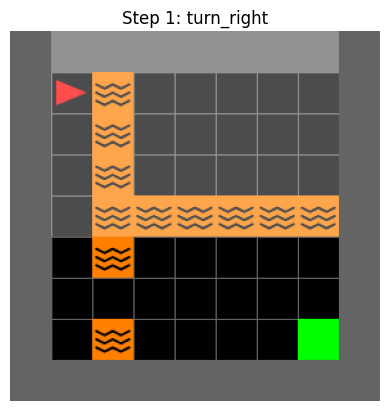


STEP 2

OBSERVATION:
 Agent at [1,1] facing down. Nearby — front: empty, left: lava, right: wall, behind: wall. The cell directly in front of you contains empty. Goal at [7,7]. Distance: 12 steps. You need to go: right, down. You are facing TOWARD the goal. Moving forward brings you CLOSER to the goal. Lava: [2,1], [2,2], [2,3], [2,4], [2,5], [2,7], [3,4], [4,4], [5,4], [6,4], [7,4]. 
  [ToT] Proposed: ['move_forward', 'turn_right']
  [ToT] Branch [move_forward -> turn_left -> turn_right -> turn_left] => score=5.0
  [ToT] Branch [turn_right -> turn_right -> turn_right -> turn_right] => score=5.0
  [ToT] => move_forward (score=5.0, 0.74s)

ToT REASONING:
 Branch [move_forward -> turn_left -> turn_right -> turn_left]: score=5.0
Branch [turn_right -> turn_right -> turn_right -> turn_right]: score=5.0
Selected: move_forward (score=5.0)

ACTION: move_forward  (latency: 0.745s)


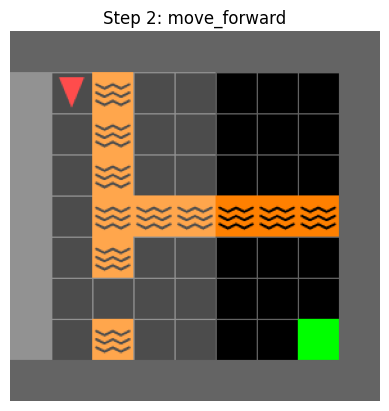


STEP 3

OBSERVATION:
 Agent at [1,2] facing down. Nearby — front: empty, left: lava, right: wall, behind: empty. The cell directly in front of you contains empty. Goal at [7,7]. Distance: 11 steps. You need to go: right, down. You are facing TOWARD the goal. Moving forward brings you CLOSER to the goal. Lava: [2,1], [2,2], [2,3], [2,4], [2,5], [2,7], [3,4], [4,4], [5,4], [6,4], [7,4]. 
  [ToT] Proposed: ['move_forward', 'turn_right']
  [ToT] Branch [move_forward -> turn_left -> turn_right -> turn_left] => score=5.0
  [ToT] Branch [turn_right -> turn_right -> turn_right -> turn_right] => score=5.0
  [ToT] => move_forward (score=5.0, 0.75s)

ToT REASONING:
 Branch [move_forward -> turn_left -> turn_right -> turn_left]: score=5.0
Branch [turn_right -> turn_right -> turn_right -> turn_right]: score=5.0
Selected: move_forward (score=5.0)

ACTION: move_forward  (latency: 0.751s)


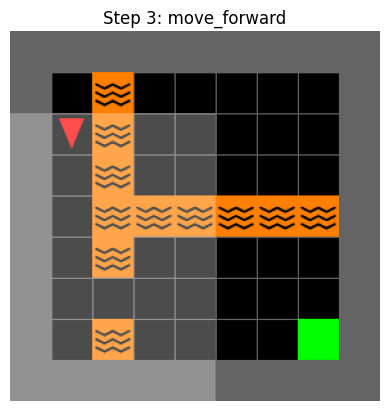


STEP 4

OBSERVATION:
 Agent at [1,3] facing down. Nearby — front: empty, left: lava, right: wall, behind: empty. The cell directly in front of you contains empty. Goal at [7,7]. Distance: 10 steps. You need to go: right, down. You are facing TOWARD the goal. Moving forward brings you CLOSER to the goal. Lava: [2,1], [2,2], [2,3], [2,4], [2,5], [2,7], [3,4], [4,4], [5,4], [6,4], [7,4]. 
  [ToT] Proposed: ['move_forward', 'turn_right']
  [ToT] Branch [move_forward -> turn_left -> turn_right -> turn_left] => score=10.0
  [ToT] Branch [turn_right -> turn_right -> turn_right -> turn_right] => score=5.0
  [ToT] => move_forward (score=10.0, 0.80s)

ToT REASONING:
 Branch [move_forward -> turn_left -> turn_right -> turn_left]: score=10.0
Branch [turn_right -> turn_right -> turn_right -> turn_right]: score=5.0
Selected: move_forward (score=10.0)

ACTION: move_forward  (latency: 0.804s)


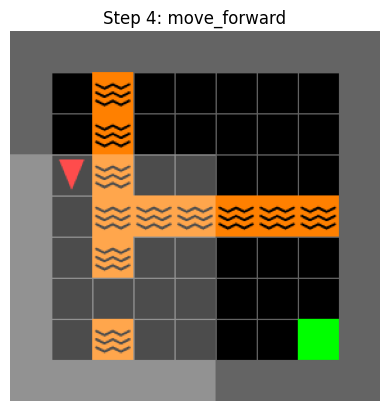


STEP 5

OBSERVATION:
 Agent at [1,4] facing down. Nearby — front: empty, left: lava, right: wall, behind: empty. The cell directly in front of you contains empty. Goal at [7,7]. Distance: 9 steps. You need to go: right, down. You are facing TOWARD the goal. Moving forward brings you CLOSER to the goal. Lava: [2,1], [2,2], [2,3], [2,4], [2,5], [2,7], [3,4], [4,4], [5,4], [6,4], [7,4]. 
  [ToT] Proposed: ['move_forward', 'turn_right']
  [ToT] Branch [move_forward -> turn_left -> turn_right -> turn_left] => score=10.0
  [ToT] Branch [turn_right -> turn_right -> turn_right -> turn_right] => score=5.0
  [ToT] => move_forward (score=10.0, 0.80s)

ToT REASONING:
 Branch [move_forward -> turn_left -> turn_right -> turn_left]: score=10.0
Branch [turn_right -> turn_right -> turn_right -> turn_right]: score=5.0
Selected: move_forward (score=10.0)

ACTION: move_forward  (latency: 0.800s)


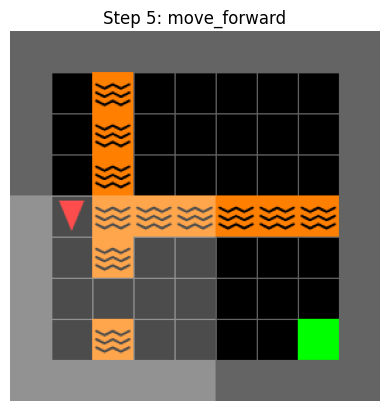


STEP 6

OBSERVATION:
 Agent at [1,5] facing down. Nearby — front: empty, left: lava, right: wall, behind: empty. The cell directly in front of you contains empty. Goal at [7,7]. Distance: 8 steps. You need to go: right, down. You are facing TOWARD the goal. Moving forward brings you CLOSER to the goal. Lava: [2,1], [2,2], [2,3], [2,4], [2,5], [2,7], [3,4], [4,4], [5,4], [6,4], [7,4]. 
  [ToT] Proposed: ['move_forward', 'turn_right']
  [ToT] Branch [move_forward -> turn_left -> move_forward -> move_forward] => score=10.0
  [ToT] Branch [turn_right -> turn_right -> turn_right -> turn_right] => score=5.0
  [ToT] => move_forward (score=10.0, 0.80s)

ToT REASONING:
 Branch [move_forward -> turn_left -> move_forward -> move_forward]: score=10.0
Branch [turn_right -> turn_right -> turn_right -> turn_right]: score=5.0
Selected: move_forward (score=10.0)

ACTION: move_forward  (latency: 0.802s)


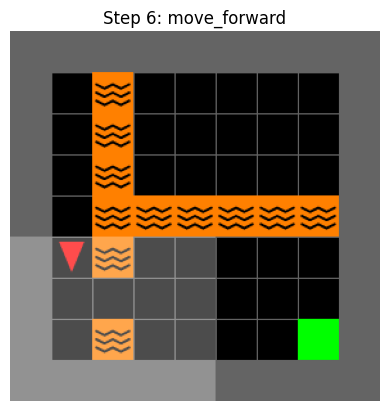


STEP 7

OBSERVATION:
 Agent at [1,6] facing down. Nearby — front: empty, left: empty, right: wall, behind: empty. The cell directly in front of you contains empty. Goal at [7,7]. Distance: 7 steps. You need to go: right, down. You are facing TOWARD the goal. Moving forward brings you CLOSER to the goal. Lava: [2,1], [2,2], [2,3], [2,4], [2,5], [2,7], [3,4], [4,4], [5,4], [6,4], [7,4]. 
  [ToT] Proposed: ['turn_right', 'move_forward']
  [ToT] Branch [turn_right -> turn_right -> turn_right -> move_forward] => score=10.0
  [ToT] Branch [move_forward -> turn_left -> turn_right -> turn_left] => score=10.0
  [ToT] => turn_right (score=10.0, 0.86s)

ToT REASONING:
 Branch [turn_right -> turn_right -> turn_right -> move_forward]: score=10.0
Branch [move_forward -> turn_left -> turn_right -> turn_left]: score=10.0
Selected: turn_right (score=10.0)

ACTION: turn_right  (latency: 0.857s)


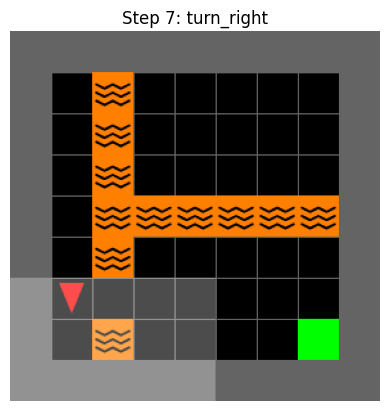


STEP 8

OBSERVATION:
 Agent at [1,6] facing left. Nearby — front: wall, left: empty, right: empty, behind: empty. The cell directly in front of you contains wall. Goal at [7,7]. Distance: 7 steps. You need to go: right, down. You are NOT facing the goal — consider turning. Lava: [2,1], [2,2], [2,3], [2,4], [2,5], [2,7], [3,4], [4,4], [5,4], [6,4], [7,4]. 
  [ToT] Proposed: ['turn_right', 'turn_left']
  [ToT] Branch [turn_right -> turn_right -> move_forward -> move_forward] => score=10.0
  [ToT] Branch [turn_left -> turn_left -> move_forward -> move_forward] => score=10.0
  [ToT] => turn_right (score=10.0, 0.86s)

ToT REASONING:
 Branch [turn_right -> turn_right -> move_forward -> move_forward]: score=10.0
Branch [turn_left -> turn_left -> move_forward -> move_forward]: score=10.0
Selected: turn_right (score=10.0)

ACTION: turn_right  (latency: 0.859s)


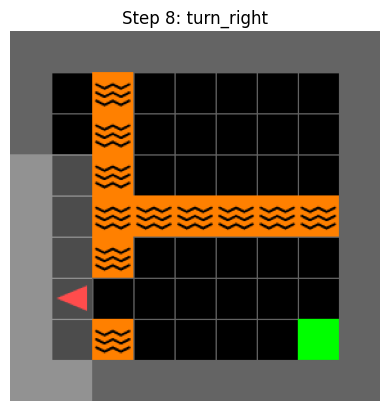


STEP 9

OBSERVATION:
 Agent at [1,6] facing up. Nearby — front: empty, left: wall, right: empty, behind: empty. The cell directly in front of you contains empty. Goal at [7,7]. Distance: 7 steps. You need to go: right, down. You are NOT facing the goal — consider turning. Moving forward takes you FARTHER from goal. Lava: [2,1], [2,2], [2,3], [2,4], [2,5], [2,7], [3,4], [4,4], [5,4], [6,4], [7,4]. 
  [ToT] Proposed: ['turn_right', 'move_forward']
  [ToT] Branch [turn_right -> move_forward -> move_forward -> move_forward] => score=10.0
  [ToT] Branch [move_forward -> turn_right -> turn_right -> turn_left] => score=1.0
  [ToT] => turn_right (score=10.0, 0.80s)

ToT REASONING:
 Branch [turn_right -> move_forward -> move_forward -> move_forward]: score=10.0
Branch [move_forward -> turn_right -> turn_right -> turn_left]: score=1.0
Selected: turn_right (score=10.0)

ACTION: turn_right  (latency: 0.797s)


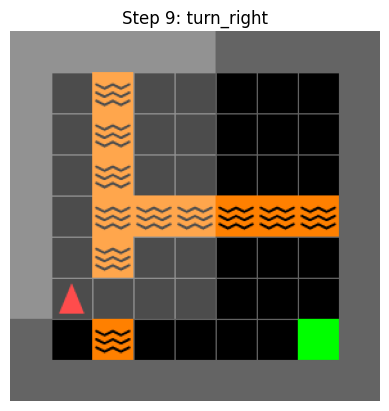


STEP 10

OBSERVATION:
 Agent at [1,6] facing right. Nearby — front: empty, left: empty, right: empty, behind: wall. The cell directly in front of you contains empty. Goal at [7,7]. Distance: 7 steps. You need to go: right, down. You are facing TOWARD the goal. Moving forward brings you CLOSER to the goal. Lava: [2,1], [2,2], [2,3], [2,4], [2,5], [2,7], [3,4], [4,4], [5,4], [6,4], [7,4]. 
  [ToT] Proposed: ['move_forward', 'turn_left']
  [ToT] Branch [move_forward -> move_forward -> move_forward -> move_forward] => score=10.0
  [ToT] Branch [turn_left -> turn_right -> move_forward -> move_forward] => score=10.0
  [ToT] => move_forward (score=10.0, 0.85s)

ToT REASONING:
 Branch [move_forward -> move_forward -> move_forward -> move_forward]: score=10.0
Branch [turn_left -> turn_right -> move_forward -> move_forward]: score=10.0
Selected: move_forward (score=10.0)

ACTION: move_forward  (latency: 0.853s)


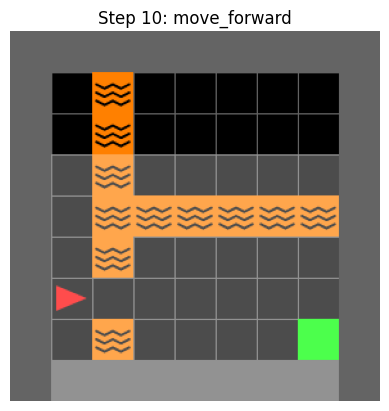


STEP 11

OBSERVATION:
 Agent at [2,6] facing right. Nearby — front: empty, left: lava, right: lava, behind: empty. The cell directly in front of you contains empty. Goal at [7,7]. Distance: 6 steps. You need to go: right, down. You are facing TOWARD the goal. Moving forward brings you CLOSER to the goal. Lava: [2,1], [2,2], [2,3], [2,4], [2,5], [2,7], [3,4], [4,4], [5,4], [6,4], [7,4]. 
  [ToT] Proposed: ['move_forward', 'turn_left']
  [ToT] Branch [move_forward -> move_forward -> move_forward -> move_forward] => score=10.0
  [ToT] Branch [turn_left -> turn_right -> move_forward -> move_forward] => score=10.0
  [ToT] => move_forward (score=10.0, 0.86s)

ToT REASONING:
 Branch [move_forward -> move_forward -> move_forward -> move_forward]: score=10.0
Branch [turn_left -> turn_right -> move_forward -> move_forward]: score=10.0
Selected: move_forward (score=10.0)

ACTION: move_forward  (latency: 0.859s)


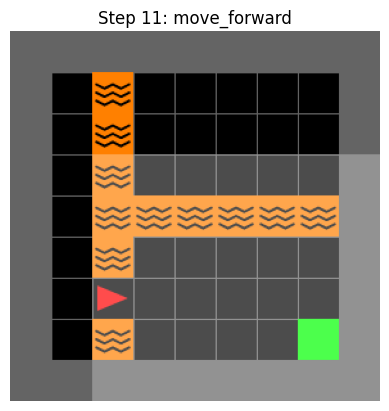


STEP 12

OBSERVATION:
 Agent at [3,6] facing right. Nearby — front: empty, left: empty, right: empty, behind: empty. The cell directly in front of you contains empty. Goal at [7,7]. Distance: 5 steps. You need to go: right, down. You are facing TOWARD the goal. Moving forward brings you CLOSER to the goal. Lava: [2,1], [2,2], [2,3], [2,4], [2,5], [2,7], [3,4], [4,4], [5,4], [6,4], [7,4]. 
  [ToT] Proposed: ['move_forward', 'turn_left']
  [ToT] Branch [move_forward -> move_forward -> move_forward -> move_forward] => score=10.0
  [ToT] Branch [turn_left -> turn_right -> move_forward -> move_forward] => score=10.0
  [ToT] => move_forward (score=10.0, 0.86s)

ToT REASONING:
 Branch [move_forward -> move_forward -> move_forward -> move_forward]: score=10.0
Branch [turn_left -> turn_right -> move_forward -> move_forward]: score=10.0
Selected: move_forward (score=10.0)

ACTION: move_forward  (latency: 0.859s)


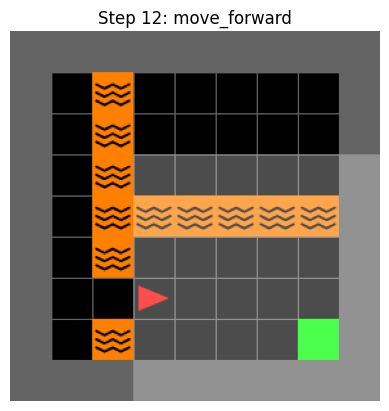


STEP 13

OBSERVATION:
 Agent at [4,6] facing right. Nearby — front: empty, left: empty, right: empty, behind: empty. The cell directly in front of you contains empty. Goal at [7,7]. Distance: 4 steps. You need to go: right, down. You are facing TOWARD the goal. Moving forward brings you CLOSER to the goal. Lava: [2,1], [2,2], [2,3], [2,4], [2,5], [2,7], [3,4], [4,4], [5,4], [6,4], [7,4]. 
  [ToT] Proposed: ['move_forward', 'turn_left']
  [ToT] Branch [move_forward -> move_forward -> move_forward -> turn_right] => score=10.0
  [ToT] Branch [turn_left -> turn_right -> move_forward -> move_forward] => score=10.0
  [ToT] => move_forward (score=10.0, 0.86s)

ToT REASONING:
 Branch [move_forward -> move_forward -> move_forward -> turn_right]: score=10.0
Branch [turn_left -> turn_right -> move_forward -> move_forward]: score=10.0
Selected: move_forward (score=10.0)

ACTION: move_forward  (latency: 0.860s)


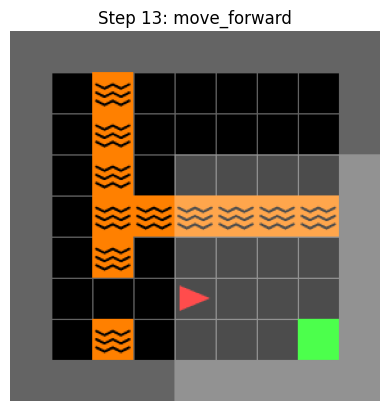


STEP 14

OBSERVATION:
 Agent at [5,6] facing right. Nearby — front: empty, left: empty, right: empty, behind: empty. The cell directly in front of you contains empty. Goal at [7,7]. Distance: 3 steps. You need to go: right, down. You are facing TOWARD the goal. Moving forward brings you CLOSER to the goal. Lava: [2,1], [2,2], [2,3], [2,4], [2,5], [2,7], [3,4], [4,4], [5,4], [6,4], [7,4]. 
  [ToT] Proposed: ['move_forward', 'turn_right']
  [ToT] Branch [move_forward -> move_forward -> turn_right -> move_forward] => score=10 (GOAL!)
  [ToT] Branch [turn_right -> turn_left -> move_forward -> move_forward] => score=10.0
  [ToT] => move_forward (score=10.0, 0.62s)

ToT REASONING:
 Branch [move_forward -> move_forward -> turn_right -> move_forward]: score=10.0
Branch [turn_right -> turn_left -> move_forward -> move_forward]: score=10.0
Selected: move_forward (score=10.0)

ACTION: move_forward  (latency: 0.625s)


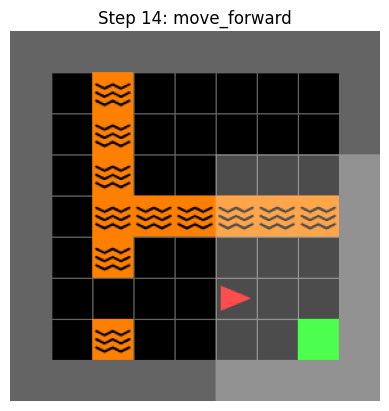


STEP 15

OBSERVATION:
 Agent at [6,6] facing right. Nearby — front: empty, left: empty, right: empty, behind: empty. The cell directly in front of you contains empty. Goal at [7,7]. Distance: 2 steps. You need to go: right, down. You are facing TOWARD the goal. Moving forward brings you CLOSER to the goal. Lava: [2,1], [2,2], [2,3], [2,4], [2,5], [2,7], [3,4], [4,4], [5,4], [6,4], [7,4]. 
  [ToT] Proposed: ['move_forward', 'turn_right']
  [ToT] Branch [move_forward -> turn_right -> move_forward -> turn_right] => score=10 (GOAL!)
  [ToT] Branch [turn_right -> turn_left -> move_forward -> turn_right] => score=10.0
  [ToT] => move_forward (score=10.0, 0.63s)

ToT REASONING:
 Branch [move_forward -> turn_right -> move_forward -> turn_right]: score=10.0
Branch [turn_right -> turn_left -> move_forward -> turn_right]: score=10.0
Selected: move_forward (score=10.0)

ACTION: move_forward  (latency: 0.626s)


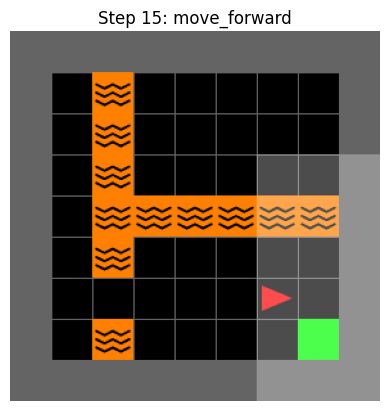

In [ ]:
import matplotlib.pyplot as plt


def debug_agent(agent, env_name="MiniGrid-Empty-8x8-v0", steps=15):
    env = MinigridTextWrapper(env_name, render_mode="rgb_array")
    obs = env.reset()
    agent.reset()

    for step in range(steps):
        print(f"\nSTEP {step + 1}")
        print("\nOBSERVATION:\n", obs)

        action, response, latency = agent.act(obs)

        print("\nToT REASONING:\n", response)
        print(f"\nACTION: {action}  (latency: {latency:.3f}s)")

        frame = env.env.render()
        plt.imshow(frame)
        plt.axis("off")
        plt.title(f"Step {step + 1}: {action}")
        plt.show()

        obs, reward, done, _ = env.step(action)
        if done:
            print(f"\nEpisode finished | reward: {reward}")
            break

    env.env.close()


agent = TreeOfThoughtAgent(
    model="Qwen/Qwen2.5-7B-Instruct",
    branch_factor=2,
    search_depth=4,
    verbose=True,
)

debug_agent(agent, env_name="MiniGrid-LavaCrossingS9N2-v0", steps=15)

In [ ]:
# # Empty-8x8
# metrics_empty = evaluate_agent(
#     agent,
#     env_name="MiniGrid-Empty-8x8-v0",
#     num_episodes=10,
#     max_steps_per_episode=100,
# )

In [ ]:
# LavaGapS6
metrics_lava = evaluate_agent(
    agent,
    env_name="MiniGrid-LavaGapS6-v0",
    num_episodes=20,
    max_steps_per_episode=100,
)

Evaluating MiniGrid-LavaGapS6-v0 for 20 episodes
  [ToT] Proposed: ['move_forward', 'turn_right']
  [ToT] Branch [move_forward -> turn_right -> move_forward -> turn_left] => score=10.0
  [ToT] Branch [turn_right -> turn_left -> move_forward -> turn_right] => score=10.0
  [ToT] => move_forward (score=10.0, 0.84s)
  [ToT] Proposed: ['turn_right', 'turn_left']
  [ToT] Branch [turn_right -> move_forward -> turn_left -> move_forward] => score=10.0
  [ToT] Branch [turn_left -> turn_right -> turn_right -> move_forward] => score=10.0
  [ToT] => turn_right (score=10.0, 0.89s)
  [ToT] Proposed: ['move_forward', 'turn_left']
  [ToT] Branch [move_forward -> turn_left -> move_forward -> turn_right] => score=10.0
  [ToT] Branch [turn_left -> turn_right -> move_forward -> turn_left] => score=10.0
  [ToT] => move_forward (score=10.0, 0.89s)
  [ToT] Proposed: ['move_forward', 'turn_left']
  [ToT] Branch [move_forward -> turn_left -> turn_right -> turn_left] => score=5.0
  [ToT] Branch [turn_left -> mov

In [ ]:
# LavaCrossingS9N2
metrics_lava = evaluate_agent(
    agent,
    env_name="MiniGrid-LavaCrossingS9N2-v0",
    num_episodes=20,
    max_steps_per_episode=100,
)

Streaming output truncated to the last 5000 lines.
  [ToT] Branch [turn_right -> turn_right -> turn_right -> turn_right] => score=5.0
  [ToT] Branch [move_forward -> turn_left -> turn_right -> turn_left] => score=5.0
  [ToT] => turn_right (score=5.0, 0.75s)
  [ToT] Proposed: ['turn_right', 'move_forward']
  [ToT] Branch [turn_right -> turn_right -> turn_right -> turn_left] => score=5.0
  [ToT] Branch [move_forward -> turn_right -> turn_right -> move_forward] => score=5.0
  [ToT] => turn_right (score=5.0, 0.75s)
  [ToT] Proposed: ['turn_left', 'turn_right']
  [ToT] Branch [turn_left -> turn_right -> turn_right -> turn_right] => score=5.0
  [ToT] Branch [turn_right -> turn_right -> turn_left -> turn_right] => score=5.0
  [ToT] => turn_left (score=5.0, 0.75s)
  [ToT] Proposed: ['turn_right', 'move_forward']
  [ToT] Branch [turn_right -> turn_right -> turn_right -> turn_left] => score=5.0
  [ToT] Branch [move_forward -> turn_right -> turn_right -> move_forward] => score=5.0
  [ToT] => turn

In [ ]:
# display(Image(filename="ToT_v2_MiniGrid-LavaCrossingS9N2-v0_ep5.gif"))